In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

In [2]:
## Load the bankruptcy_helper module

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Reload all modules imported with %aimport
%load_ext autoreload
%autoreload 1

# Import bankruptcy_helper module
import bankruptcy_helper
%aimport bankruptcy_helper

helper = bankruptcy_helper.Helper()

In [3]:
import os
DATA_DIR = "./Data"

if not os.path.isdir(DATA_DIR):
    DATA_DIR = "../resource/asnlib/publicdata/bankruptcy/data"

data_file = "5th_yr.csv"
data = pd.read_csv( os.path.join(DATA_DIR, "train", data_file) )

target_attr = "Bankrupt"

n_samples, n_attrs = data.shape
print("Date shape: ", data.shape)

Date shape:  (4818, 66)


In [4]:
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X57,X58,X59,X60,X61,X62,X63,X64,Bankrupt,Id
0,0.025417,0.41769,0.0568,1.1605,-126.39,0.41355,0.025417,1.2395,1.16500,0.51773,...,0.049094,0.85835,0.12322,5.6167,7.4042,164.310,2.2214,1.334,0,4510
1,-0.023834,0.2101,0.50839,4.2374,22.034,0.058412,-0.027621,3.6579,0.98183,0.76855,...,-0.031011,1.01850,0.069047,5.7996,7.7529,26.446,13.802,6.4782,0,3537
2,0.030515,0.44606,0.19569,1.565,35.766,0.28196,0.039264,0.88456,1.05260,0.39457,...,0.077337,0.95006,0.25266,15.049,2.8179,104.730,3.4852,2.6361,0,3920
3,0.052318,0.056366,0.54562,10.68,438.2,0.13649,0.058164,10.853,1.02790,0.61173,...,0.085524,0.97282,0,6.0157,7.4626,48.756,7.4863,1.0602,0,1806
4,0.000992,0.49712,0.12316,1.3036,-71.398,0,0.001007,1.0116,1.29210,0.50288,...,0.001974,0.99925,0.019736,3.4819,8.582,114.580,3.1854,2.742,0,1529


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4818 entries, 0 to 4817
Data columns (total 66 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X1        4818 non-null   object 
 1   X2        4818 non-null   object 
 2   X3        4818 non-null   object 
 3   X4        4818 non-null   object 
 4   X5        4818 non-null   object 
 5   X6        4818 non-null   object 
 6   X7        4818 non-null   object 
 7   X8        4818 non-null   object 
 8   X9        4818 non-null   float64
 9   X10       4818 non-null   object 
 10  X11       4818 non-null   object 
 11  X12       4818 non-null   object 
 12  X13       4818 non-null   float64
 13  X14       4818 non-null   object 
 14  X15       4818 non-null   object 
 15  X16       4818 non-null   object 
 16  X17       4818 non-null   object 
 17  X18       4818 non-null   object 
 18  X19       4818 non-null   float64
 19  X20       4818 non-null   float64
 20  X21       4818 non-null   obje

In [6]:
data = data.apply(pd.to_numeric, errors='coerce')
print(data.isnull().sum())
data.fillna(data.mean(), inplace=True)

X1           2
X2           2
X3           2
X4          15
X5          10
            ..
X62          0
X63         15
X64         83
Bankrupt     0
Id           0
Length: 66, dtype: int64


In [7]:
print("Class Distribution:")
print(data['Bankrupt'].value_counts())

Class Distribution:
Bankrupt
0    4510
1     308
Name: count, dtype: int64


<Figure size 600x400 with 0 Axes>

/var/folders/t7/dpdxvfdj2l7g8rntzy7zzlm80000gn/T/ipykernel_19566/262090298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Bankrupt', data=data, palette='Set2')


<Axes: xlabel='Bankrupt', ylabel='count'>

Text(0.5, 1.0, 'Class Distribution (Bankrupt vs Not Bankrupt)')

Text(0.5, 0, 'Bankrupt (1 = Yes, 0 = No)')

Text(0, 0.5, 'Count')

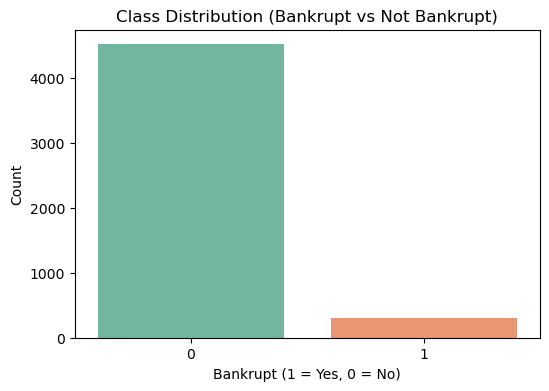

In [8]:
import seaborn as sns 
plt.figure(figsize=(6, 4))
sns.countplot(x='Bankrupt', data=data, palette='Set2')
plt.title('Class Distribution (Bankrupt vs Not Bankrupt)')
plt.xlabel('Bankrupt (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

In [9]:
print("\nMissing Values Analysis:")
print(data.isnull().sum())


Missing Values Analysis:
X1          0
X2          0
X3          0
X4          0
X5          0
           ..
X62         0
X63         0
X64         0
Bankrupt    0
Id          0
Length: 66, dtype: int64


In [10]:
data.fillna(data.mean(), inplace=True)

In [11]:
print("\nDescriptive Statistics:")
print(data.describe())


Descriptive Statistics:
                X1           X2           X3           X4            X5  \
count  4818.000000  4818.000000  4818.000000  4818.000000  4.818000e+03   
mean     -0.055232     0.533272     0.188992     4.978602  1.956441e+01   
std       6.705958     1.202660     1.282164   100.117705  2.382015e+04   
min    -463.890000     0.000000   -72.067000     0.000000 -1.076400e+06   
25%       0.004042     0.254765     0.044978     1.101525 -4.290075e+01   
50%       0.046428     0.451610     0.218155     1.645450  4.932050e-01   
75%       0.116725     0.662140     0.420033     2.943000  4.978025e+01   
max       2.352300    72.416000    28.336000  6845.800000  1.250100e+06   

                X6           X7           X8           X9          X10  ...  \
count  4818.000000  4818.000000  4818.000000  4818.000000  4818.000000  ...   
mean     -0.070060    -0.042516     5.739985     1.579277     0.503606  ...   
std       7.776908     6.706577   109.348749     1.342723     

<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix')

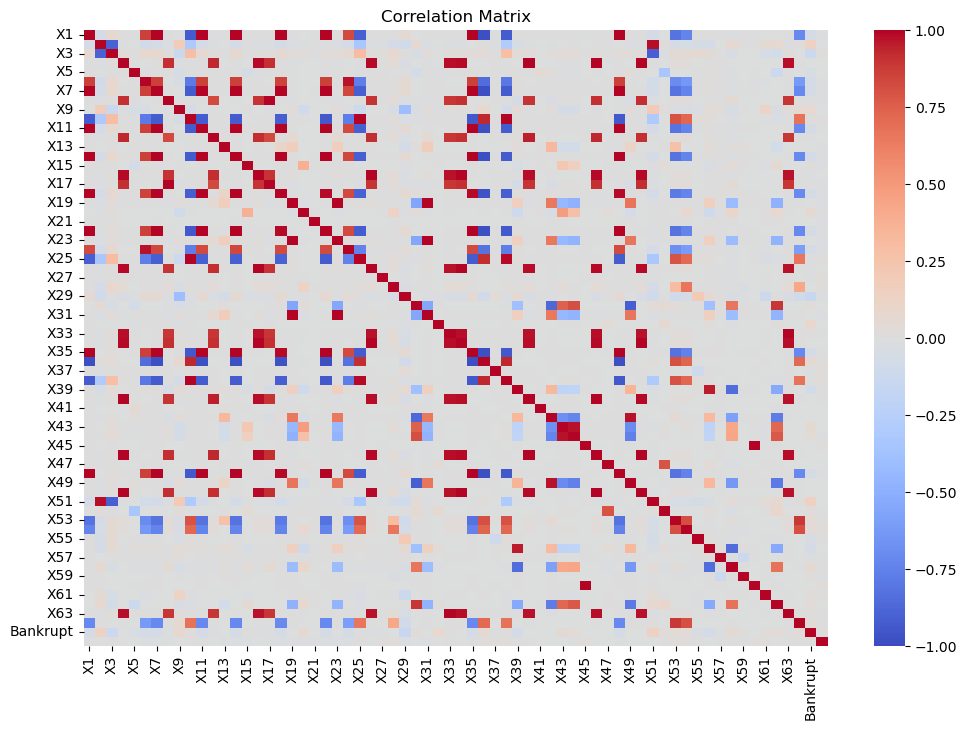

In [12]:
corr_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title('Correlation Matrix')
plt.show()

In [13]:
print("\nCorrelation with Target Variable (Bankrupt):")
print(corr_matrix['Bankrupt'].sort_values(ascending=False)[:11])


Correlation with Target Variable (Bankrupt):
Bankrupt    1.000000
X2          0.138728
X51         0.133541
X32         0.079572
X9          0.076021
X36         0.061084
X20         0.055927
X58         0.052528
X43         0.052071
X44         0.043092
X53         0.040714
Name: Bankrupt, dtype: float64


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X2', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X2')

Text(0.5, 0, 'X2')

Text(0, 0.5, 'Frequency')

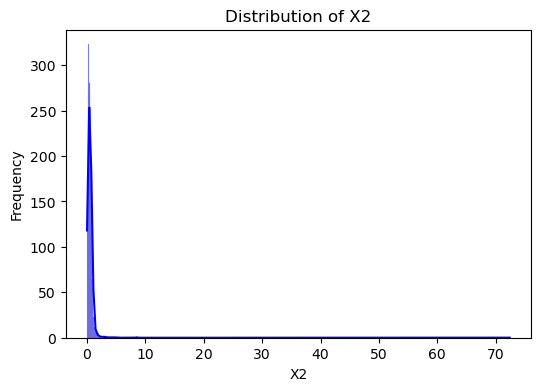

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X51', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X51')

Text(0.5, 0, 'X51')

Text(0, 0.5, 'Frequency')

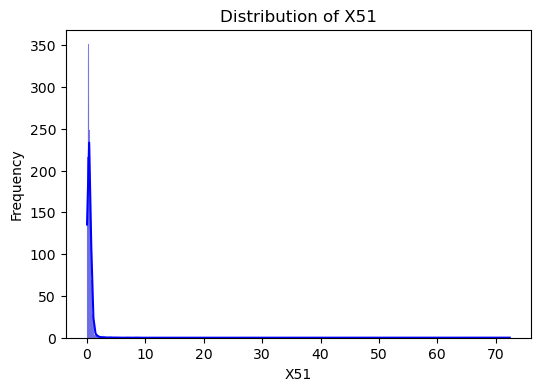

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X32', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X32')

Text(0.5, 0, 'X32')

Text(0, 0.5, 'Frequency')

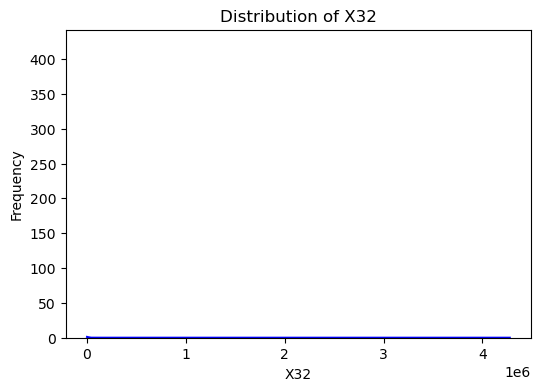

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X9', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X9')

Text(0.5, 0, 'X9')

Text(0, 0.5, 'Frequency')

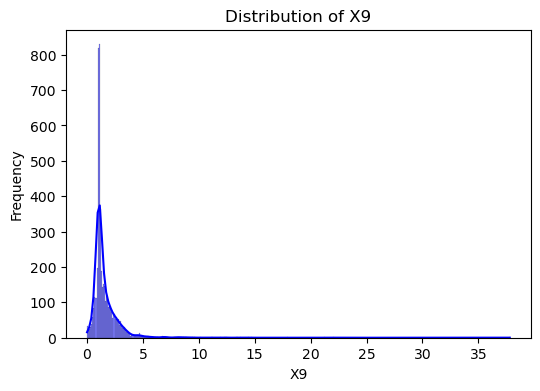

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X36', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X36')

Text(0.5, 0, 'X36')

Text(0, 0.5, 'Frequency')

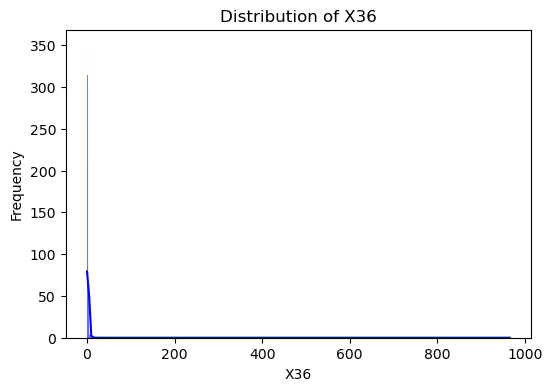

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X20', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X20')

Text(0.5, 0, 'X20')

Text(0, 0.5, 'Frequency')

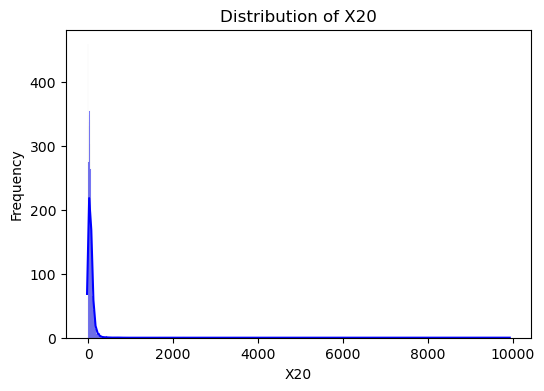

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X58', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X58')

Text(0.5, 0, 'X58')

Text(0, 0.5, 'Frequency')

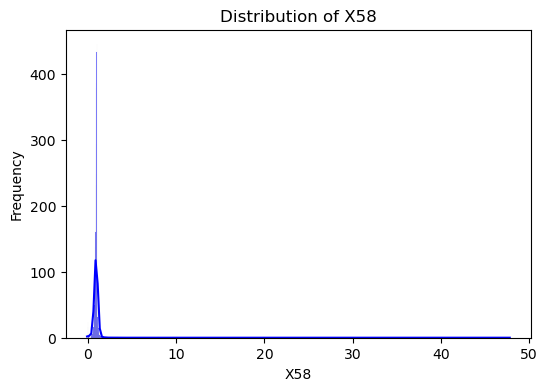

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X43', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X43')

Text(0.5, 0, 'X43')

Text(0, 0.5, 'Frequency')

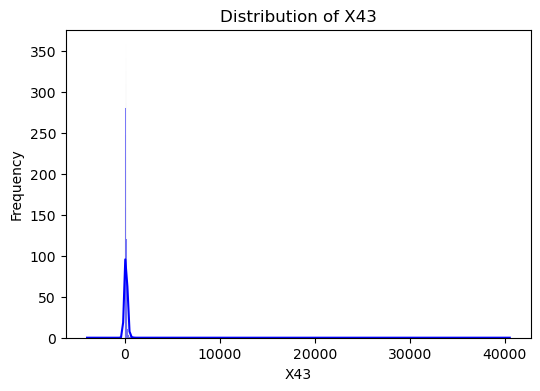

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X44', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X44')

Text(0.5, 0, 'X44')

Text(0, 0.5, 'Frequency')

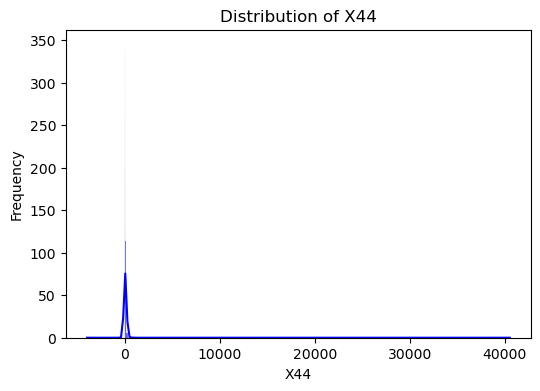

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X53', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X53')

Text(0.5, 0, 'X53')

Text(0, 0.5, 'Frequency')

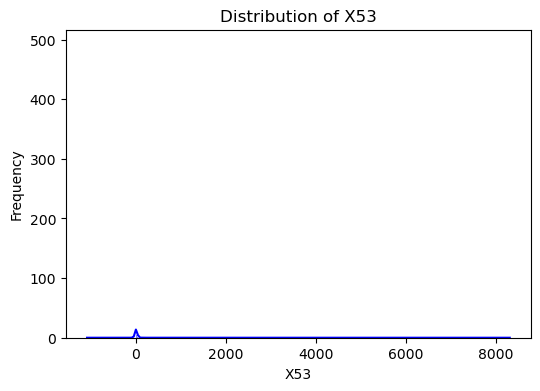

In [14]:
selected_features = ['X2', 'X51', 'X32', 'X9','X36','X20','X58','X43','X44','X53'] 
for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

Text(0.5, 1.02, 'Pairwise Relationships Between Features')

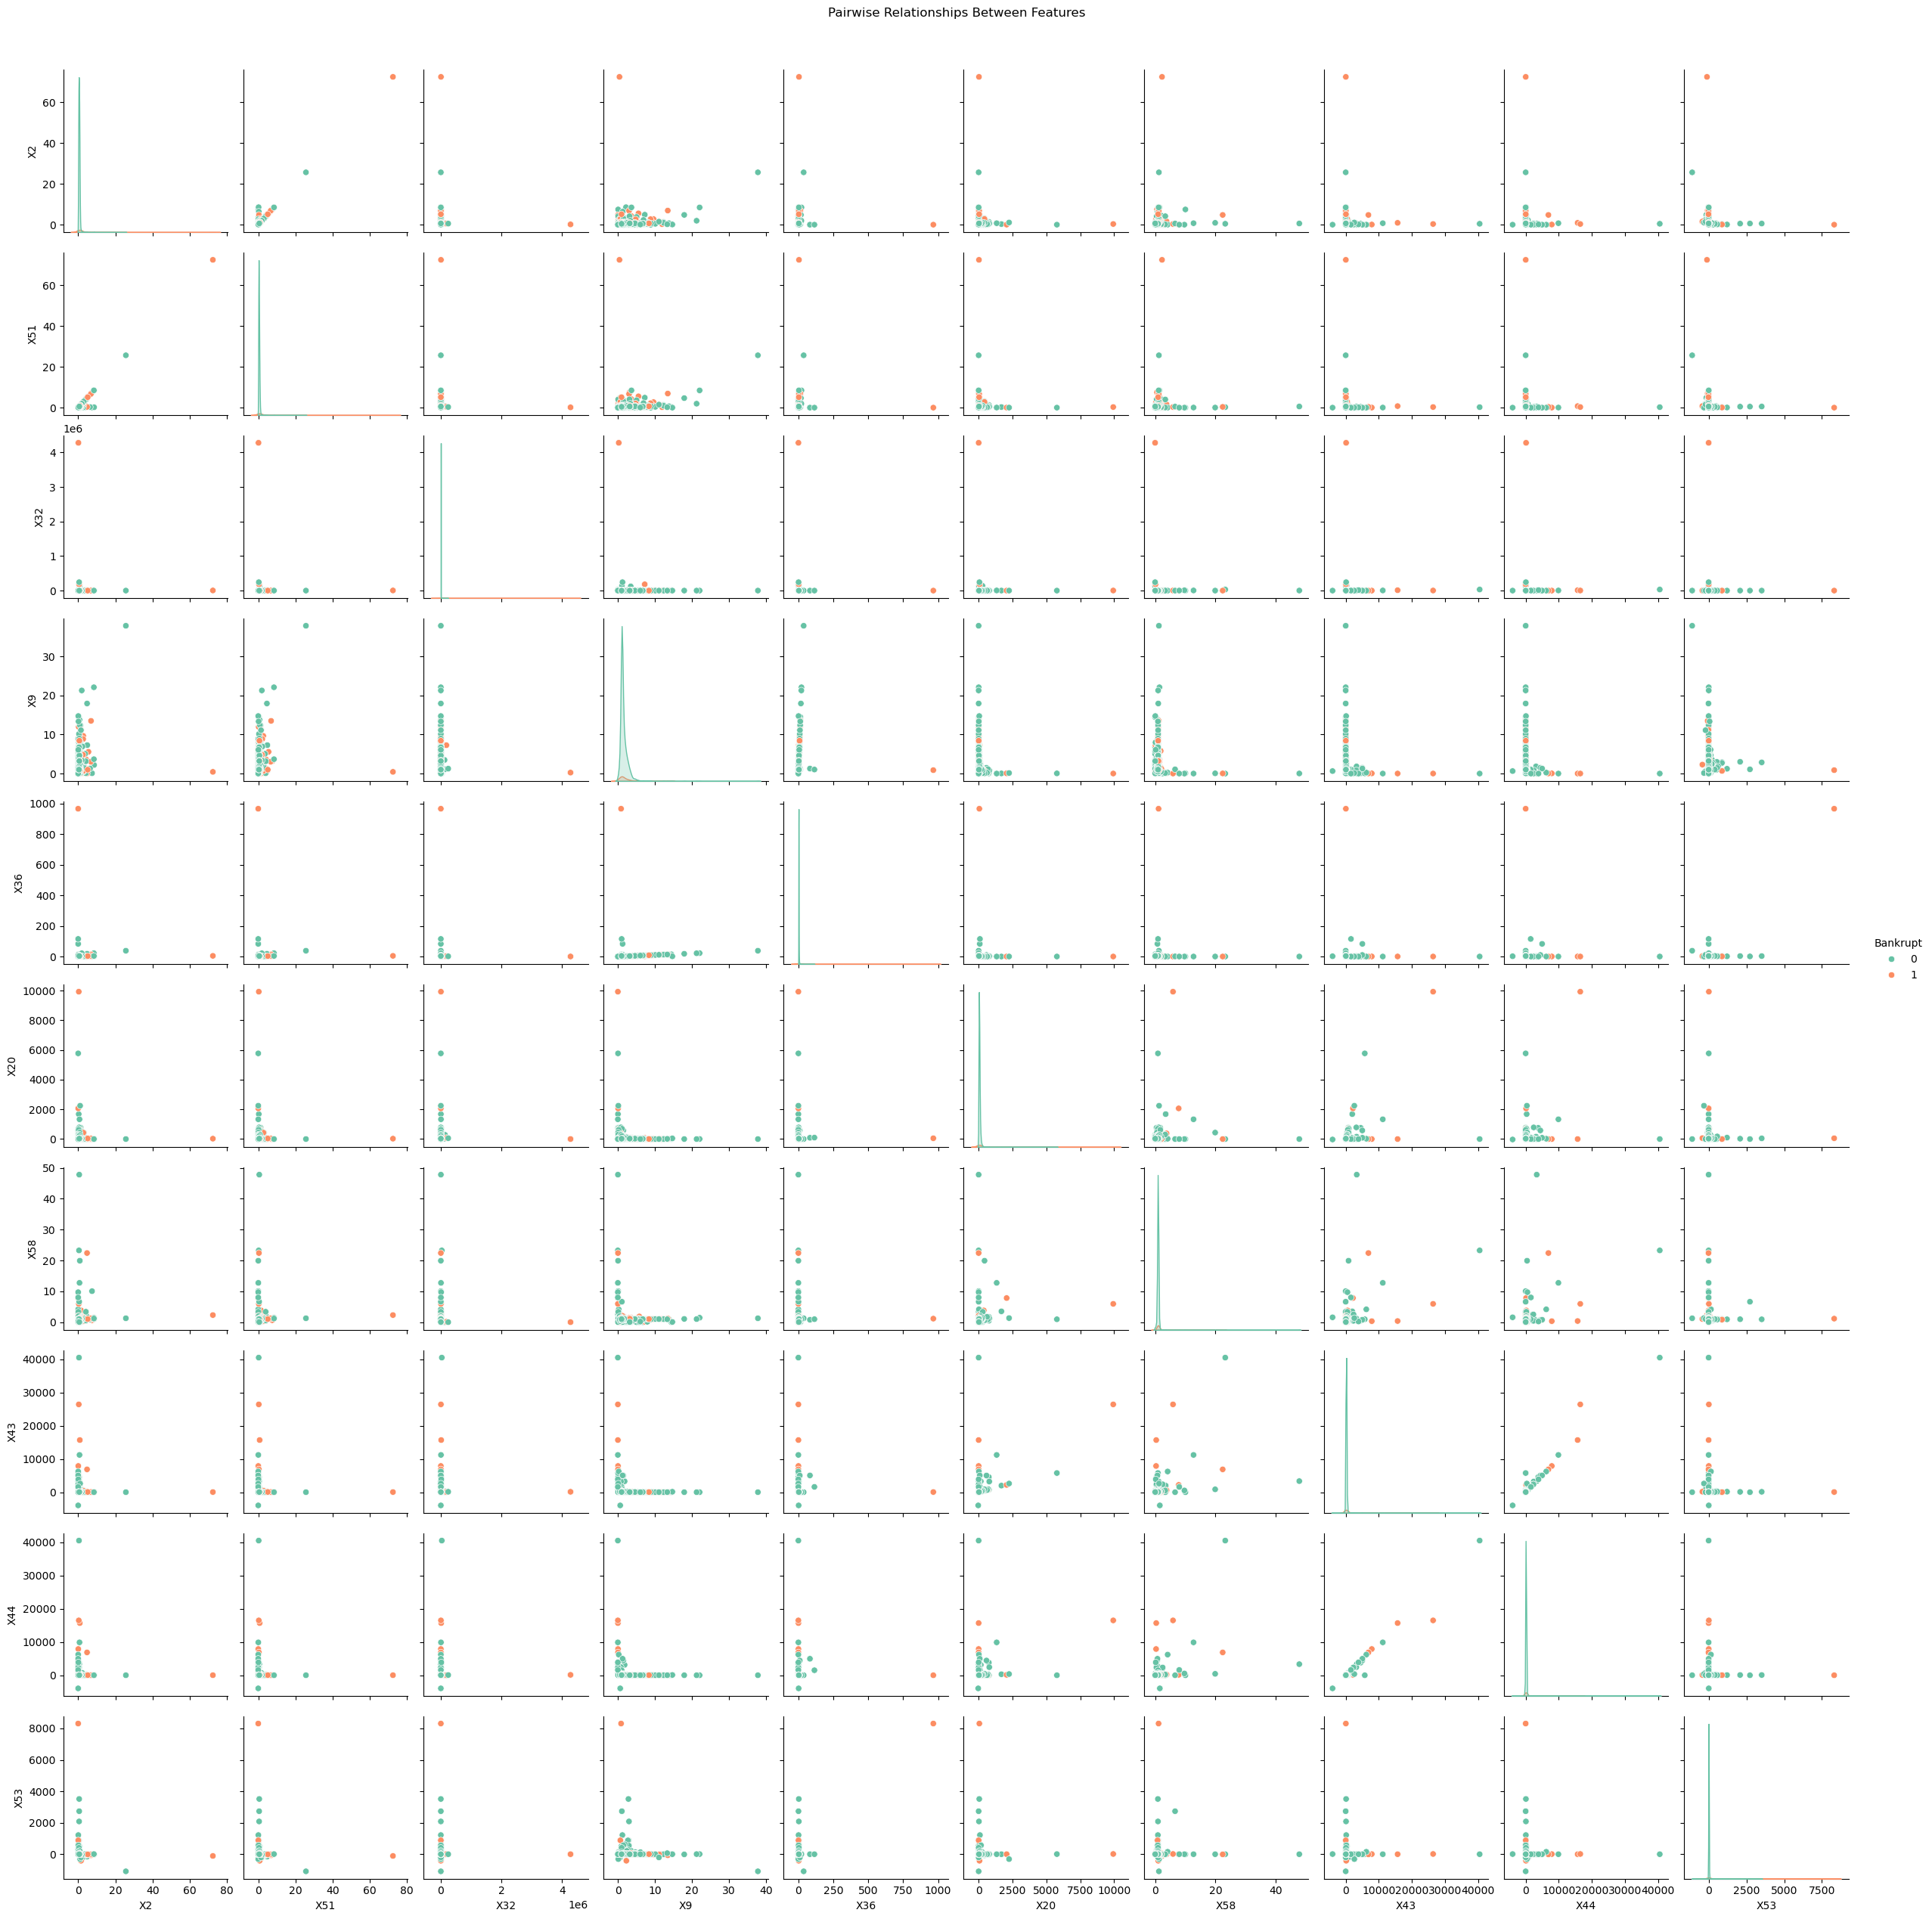

In [15]:
sns.pairplot(data[selected_features + ['Bankrupt']], hue='Bankrupt', palette='Set2')
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

In [16]:
X = data.drop(columns=['Bankrupt', 'Id'])
y = data['Bankrupt']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
model = RandomForestClassifier(random_state=42, n_estimators=1000)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [16]:
def MyModel(data, other={}):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    data = data.apply(pd.to_numeric, errors='coerce')
    data.fillna(data.mean(), inplace=True)
    if 'Id' in data.columns:
        data = data.drop(columns=['Id'])
    data_scaled = scaler.transform(data)
    pred = model.predict(data_scaled)
    return pred

In [32]:
X_test

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,Id
1140,0.202346,0.112039,-0.056712,-0.038597,-0.000070,-0.005729,0.241469,-0.045712,1.317007,-0.091782,...,0.009005,0.068676,-0.028066,-0.064845,-0.005162,-0.134877,-0.049190,-0.038267,-0.053237,0.909959
4744,-0.138753,0.024855,-0.192724,-0.041502,-0.002890,-0.000175,-0.158484,-0.043475,-0.434165,-0.019585,...,-0.085845,-0.009276,0.050467,-0.035037,-0.018417,-0.109367,-0.027594,-0.054437,-0.134301,-1.538418
1939,-0.138273,-0.003769,0.126901,-0.033911,-0.000562,-0.013330,-0.156338,-0.042223,-0.406453,0.017548,...,-0.040866,-0.007504,0.013971,-0.059805,-0.018461,-0.144499,-0.040840,-0.046848,-0.049111,-0.238812
322,0.080082,-0.184343,0.308730,-0.021283,0.000463,-0.005729,0.071688,-0.028551,4.580639,0.196908,...,-0.039151,0.019488,0.014191,-0.064845,-0.005162,0.018052,-0.071638,0.134014,0.396242,-0.120146
2204,0.127337,-0.266849,0.218916,-0.015115,0.001637,-0.005729,0.150031,-0.009013,0.252832,0.277274,...,0.030961,0.021694,-0.042216,-0.064845,-0.018412,-0.128529,-0.064725,0.010361,-0.114020,-1.035875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,-0.169100,-0.006976,-0.105837,-0.039209,-0.002279,0.039792,-0.214321,-0.042017,-0.367076,0.024144,...,0.085445,0.005319,0.018225,0.006903,-0.018413,-0.115860,-0.035361,-0.050580,-0.138035,-1.155256
3969,-0.156734,0.357120,-0.181793,-0.040484,-0.001929,-0.028686,-0.176255,-0.049611,1.658300,-0.330518,...,-0.060041,0.182512,0.038982,-0.265645,-0.018398,0.245653,-0.043074,-0.044973,0.044815,0.892088
262,0.097876,0.080266,0.079783,-0.032898,0.000076,-0.005729,0.110374,-0.044909,0.525002,-0.060833,...,-0.007509,0.038398,-0.020651,0.039669,-0.018387,-0.103721,-0.055668,-0.026850,-0.109054,-1.719276
4807,-0.057716,0.077102,-0.075441,-0.038437,-0.000935,-0.004374,-0.073868,-0.045100,-0.387189,-0.072880,...,-0.011556,0.005415,-0.009799,0.046855,-0.018224,-0.126276,-0.041252,-0.046521,-0.129242,0.120045


In [29]:
X_test_df = pd.DataFrame(X_test, columns=selected_features)
name = "Random Forest Classifier"
y_test_pred = MyModel(X_test_df)

In [30]:
accuracy_test = accuracy_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred, pos_label=1, average="binary")
precision_test = precision_score(y_test, y_test_pred, pos_label=1, average="binary")
print("\t{m:s} Accuracy: {a:3.1%}, Recall {r:3.1%}, Precision {p:3.1%}".format(
    m=name,
    a=accuracy_test,
    r=recall_test,
    p=precision_test
))

	Random Forest Classifier Accuracy: 92.8%, Recall 1.4%, Precision 100.0%


<Figure size 600x600 with 0 Axes>

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(45.72222222222221, 0.5, 'Actual')

Text(0.5, 1.0, 'Confusion Matrix')

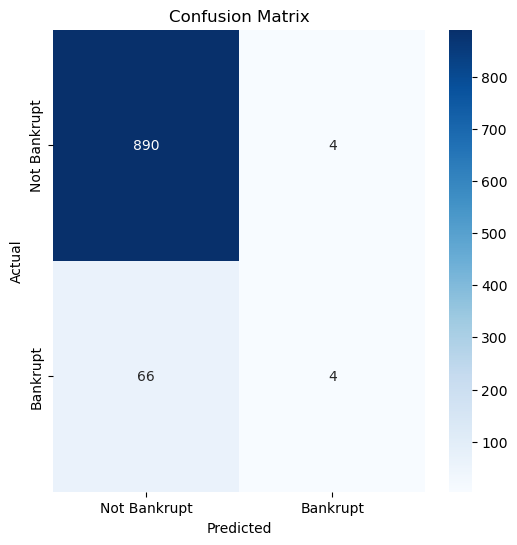

In [26]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
import seaborn as sns
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Bankrupt', 'Bankrupt'], 
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [33]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
roc_auc = roc_auc_score(y_test, y_test_pred)
print(f"ROC-AUC Score: {roc_auc:.3f}")

ROC-AUC Score: 0.520


In [35]:
precision, recall, _ = precision_recall_curve(y_test, y_test_pred)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.3f}")

Precision-Recall AUC: 0.306


In [17]:
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.svm import LinearSVC, SVC
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_recall_curve, recall_score, precision_score, accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [18]:
def preprocess_inputs(df):
    df = df.copy()
    y = df['Bankrupt']
    X = df.drop('Bankrupt', axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
    return X_train, X_test, y_train, y_test

In [19]:
X_train, X_test, y_train, y_test = preprocess_inputs(data)

In [20]:
X_train

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,Id
3771,0.105934,0.095661,-0.029835,-0.038054,-0.001085,-0.005729,0.121146,-0.045311,0.817993,-0.075829,...,-0.006476,0.042413,-0.015368,-0.064845,-0.018397,-0.092230,-0.043647,-0.044452,-0.068774,0.758410
666,0.487361,0.395500,-0.182443,-0.040405,-0.000871,-0.289262,0.500648,-0.050001,1.370620,-0.367863,...,-0.024072,-0.418695,-0.062440,-0.064845,-0.015779,-0.153728,-0.034729,-0.050948,0.073839,-1.492667
171,-0.034990,0.001525,-0.127787,-0.040095,-0.002397,-0.005729,-0.042951,-0.042355,-0.355319,0.015864,...,-0.003304,0.009044,0.006436,-0.003823,-0.018432,-0.026480,-0.041845,-0.046035,-0.138920,-1.742151
1176,0.274578,-0.077653,-0.048206,-0.036166,0.000432,-0.005729,0.331877,-0.038487,0.114020,0.092987,...,0.128488,0.048395,-0.108841,-0.010969,-0.005162,-0.091711,-0.057517,-0.022155,-0.131984,1.689151
1077,0.024098,-0.005390,0.085372,-0.034995,-0.000101,-0.005729,0.035062,-0.042081,0.345467,0.022600,...,0.015134,0.018276,-0.005995,-0.064845,-0.018425,-0.152023,-0.041777,-0.046091,-0.075034,0.731960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,0.091114,-0.126794,-0.014310,-0.034571,-0.001433,-0.005729,0.104530,-0.034914,-0.376991,0.140853,...,0.082272,0.022554,-0.073264,-0.045599,-0.018469,-0.094390,-0.044465,-0.043675,-0.137244,1.370326
2763,0.133313,0.053371,-0.091447,-0.039047,-0.001756,0.029195,0.162188,-0.044254,-0.345121,-0.040604,...,0.047442,0.042771,-0.057643,-0.023454,-0.018420,-0.077796,-0.040207,-0.047338,-0.122085,0.983589
905,-0.057212,0.084764,-0.165809,-0.042415,-0.002780,-0.005729,-0.075015,-0.045029,-0.722037,-0.065214,...,-0.053901,0.005521,0.021404,-0.013302,-0.018262,-0.125071,-0.025853,-0.055137,-0.143596,-0.481863
3980,0.182891,-0.059639,0.169170,-0.031979,0.002351,-0.005729,0.160481,-0.039531,0.145324,0.075441,...,0.036148,0.037975,-0.049787,-0.064845,-0.018179,-0.174074,-0.041977,-0.045925,-0.059301,1.697014


In [21]:
y_train

3771    0
666     0
171     0
1176    0
1077    0
       ..
2895    0
2763    0
905     0
3980    0
235     0
Name: Bankrupt, Length: 3372, dtype: int64

In [41]:
original_models = {
    "                   Logistic Regression": LogisticRegression(),
    "                   K-Nearest Neighbors": KNeighborsClassifier(),
    "                         Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine (Linear Kernel)": LinearSVC(),
    "   Support Vector Machine (RBF Kernel)": SVC(),
    "                         Random Forest": RandomForestClassifier(),
}

for name, model in original_models.items():
    model.fit(X_train, y_train)
    print(name + " trained.")

LogisticRegression()

                   Logistic Regression trained.


KNeighborsClassifier()

                   K-Nearest Neighbors trained.


DecisionTreeClassifier()

...

Support Vector Machine (Linear Kernel) trained.


SVC()

   Support Vector Machine (RBF Kernel) trained.


RandomForestClassifier()

                         Random Forest trained.


In [42]:
original_results = []
for name, model in original_models.items():
    result = model.score(X_test, y_test)
    original_results.append(result)
    print(name + ": {:.2f}%".format(result * 100))

                   Logistic Regression: 93.91%
                   K-Nearest Neighbors: 93.91%
                         Decision Tree: 94.61%
Support Vector Machine (Linear Kernel): 93.98%
   Support Vector Machine (RBF Kernel): 94.05%
                         Random Forest: 95.37%


In [43]:
n_components = 10
pca = PCA(n_components=n_components)
pca.fit(X_train)
X_train_reduced = pd.DataFrame(pca.transform(X_train), index=X_train.index, columns=["PC" + str(i) for i in range(1, n_components + 1)])
X_test_reduced = pd.DataFrame(pca.transform(X_test), index=X_test.index, columns=["PC" + str(i) for i in range(1, n_components + 1)])

PCA(n_components=10)

In [44]:
X_test_reduced

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
1140,-0.079825,0.149185,0.197475,0.342545,0.891874,-0.514992,-0.011555,0.447283,-0.424895,-0.280662
4744,-0.222959,-0.334631,0.055568,-0.361110,-0.417560,0.071236,-0.050437,-0.158967,0.127815,0.194180
1939,-0.168825,-0.173811,0.061226,-0.145458,-0.186734,0.080686,-0.021399,-0.195085,-0.019085,0.049966
322,0.119819,0.090549,0.318519,0.678206,1.543686,-1.123735,-0.141752,1.106717,-0.981422,-1.194184
2204,0.092969,0.683120,0.076923,-0.131422,0.263430,-0.099613,-0.053185,0.045642,-0.089642,0.014081
...,...,...,...,...,...,...,...,...,...,...
546,-0.178857,-0.056723,0.113019,-0.371822,-0.054469,0.294308,-0.030319,-0.269936,0.114899,0.295788
3969,-0.307882,-1.041834,0.328120,0.201130,0.360832,-0.512054,-0.048814,0.499411,-0.653922,-0.555367
262,-0.081104,0.146617,0.146827,0.024698,0.286522,-0.269256,-0.081221,0.212625,-0.201423,-0.075690
4807,-0.177664,-0.088498,0.107112,-0.306252,-0.051800,0.153124,-0.000476,-0.234227,0.046785,0.193189


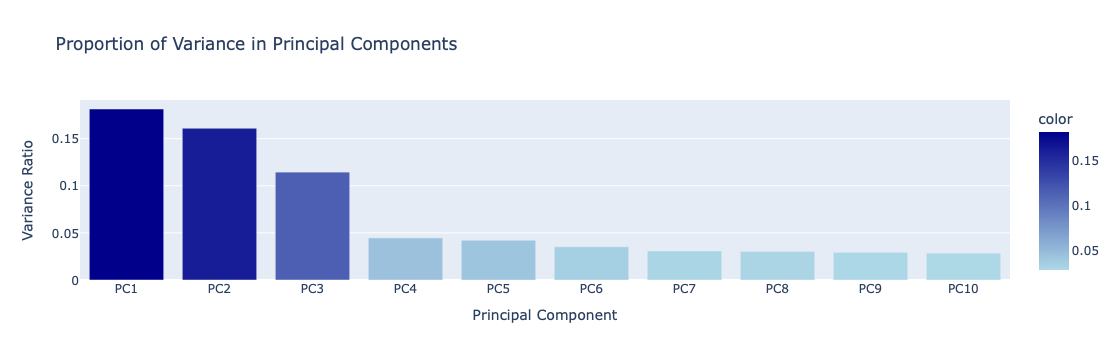

In [45]:
import plotly.express as px

fig = px.bar(
    x=["PC" + str(i) for i in range(1, n_components + 1)],
    y=pca.explained_variance_ratio_,
    labels={'x': "Principal Component", 'y': "Variance Ratio"},
    color=pca.explained_variance_ratio_,
    color_continuous_scale=[(0, 'lightblue'), (1, 'darkblue')],
    title="Proportion of Variance in Principal Components"
)

fig.show()

In [46]:
def MyModel(data, other={}):
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    data = data.apply(pd.to_numeric, errors='coerce')
    data.fillna(data.mean(), inplace=True)
    if 'Id' in data.columns:
        data = data.drop(columns=['Id'])
    data_scaled = scaler.transform(data)
    pred = model.predict(data_scaled)
    return pred

In [49]:
X_train_reduced

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
3771,-0.109951,0.076666,0.167625,0.159285,0.608196,-0.313638,-0.018785,0.211924,-0.224399,-0.098431
666,-0.094269,-0.078782,0.232653,0.753266,0.752887,-0.632743,-0.099177,0.644537,-0.516502,-0.544973
171,-0.140207,-0.020019,0.106537,-0.224698,-0.258750,0.007051,-0.059852,-0.039802,-0.022320,0.106946
1176,0.060466,0.766569,0.184859,0.308676,0.729472,-0.291797,0.035705,0.273494,-0.308417,-0.135894
1077,-0.096451,0.135401,0.097663,0.047715,0.301964,-0.138135,-0.010163,0.088445,-0.120278,-0.040711
...,...,...,...,...,...,...,...,...,...,...
2895,-0.047104,0.478786,0.090814,-0.238773,0.088866,0.152792,0.029954,-0.123664,0.076101,0.146197
2763,-0.090748,0.291295,0.133160,0.009772,0.401697,-0.036479,0.015836,-0.044757,-0.019171,0.137355
905,-0.184525,-0.140886,0.040309,-0.358872,-0.453838,0.156359,-0.009500,-0.249406,0.064994,0.225761
3980,-0.017290,0.439640,0.076286,0.166779,0.328916,-0.136510,0.018515,0.092530,-0.189309,-0.105084


In [50]:
print("Features seen during training:", scaler.feature_names_in_)
print("Features in X_test_df:", X_test_df.columns.tolist())

Features seen during training: ['PC1' 'PC2' 'PC3' 'PC4' 'PC5' 'PC6' 'PC7' 'PC8' 'PC9' 'PC10']
Features in X_test_df: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']


In [57]:
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_train_pca = pca.fit_transform(X_train_scaled)
model.fit(X_train_pca, y_train)

RandomForestClassifier()

In [58]:
X_test_scaled = scaler.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
X_test_df = pd.DataFrame(X_test_pca, columns=[f'PC{i}' for i in range(1, 11)])  # Match PCA training names
y_test_pred = MyModel(X_test_df)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Id
- X1
- X10
- X11
- X12
- ...
Feature names seen at fit time, yet now missing:
- PC1
- PC10
- PC2
- PC3
- PC4
- ...
